
# MemoLogs — Multimodal Embedding Evaluation

This notebook evaluates the multimodal representation used in Part A.

For every creative we generate:

**Image → CLIP Image Encoder → 512D image embedding**

**OCR text → CLIP Text Encoder → 512D text embedding**

**Image + Text → weighted fusion → 512D fused embedding**

The notebook evaluates:

1. Image preprocessing and dimensions
2. Image embeddings
3. Text embeddings
4. Image-text alignment
5. Multimodal fusion
6. Embedding dimensionality
7. Vector distributions
8. PCA visualization
9. Nearest-neighbor retrieval
10. Image vs text vs fused retrieval comparison
11. Retrieval examples for qualitative inspection



## 1. Imports and configuration


In [1]:
from pathlib import Path
import sys

# notebooks/ -> srcA/ -> project root
PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if PROJECT_ROOT.name == "srcA":
    SRC_ROOT = PROJECT_ROOT
    PROJECT_ROOT = PROJECT_ROOT.parent
else:
    SRC_ROOT = PROJECT_ROOT / "srcA"

sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

# Notebook is inside:
# srcA/notebooks/embeddings.ipynb
#
# Therefore:
# notebooks -> srcA -> project root

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if PROJECT_ROOT.name == "srcA":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

from srcA.data import load_creatives

from srcA.embeddings import (
    load_embedding_model,
    encode_images,
    encode_texts,
    fuse_embeddings,
    normalize_embeddings,
)

from srcA.config import (
    IMAGES_DIR,
    EMBEDDING_DIMENSION,
)

from srcA.config import (
    EMBEDDING_BATCH_SIZE,
    EMBEDDING_DIMENSION,
    EMBEDDING_METADATA_PATH,
    FUSED_EMBEDDINGS_DIR,
    FUSED_EMBEDDINGS_PATH,
    IMAGE_EMBEDDINGS_DIR,
    IMAGE_EMBEDDINGS_PATH,
    IMAGE_EMBEDDING_WEIGHT,
    IMAGE_TEXT_MODEL,
    IMAGES_DIR,
    TEXT_EMBEDDINGS_DIR,
    TEXT_EMBEDDINGS_PATH,
    TEXT_EMBEDDING_WEIGHT,
)

/Users/vanshikaarora/Downloads/memologs_aiml_takehome/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



## 2. Dataset overview


In [3]:

creatives = load_creatives()

print(f"Creatives: {len(creatives):,}")
print(f"Expected embedding dimension: {EMBEDDING_DIMENSION}")


Creatives: 2,882
Expected embedding dimension: 512



## 3. Creative preview

Before looking at vectors, inspect the actual visual input and the OCR text supplied by the dataset.


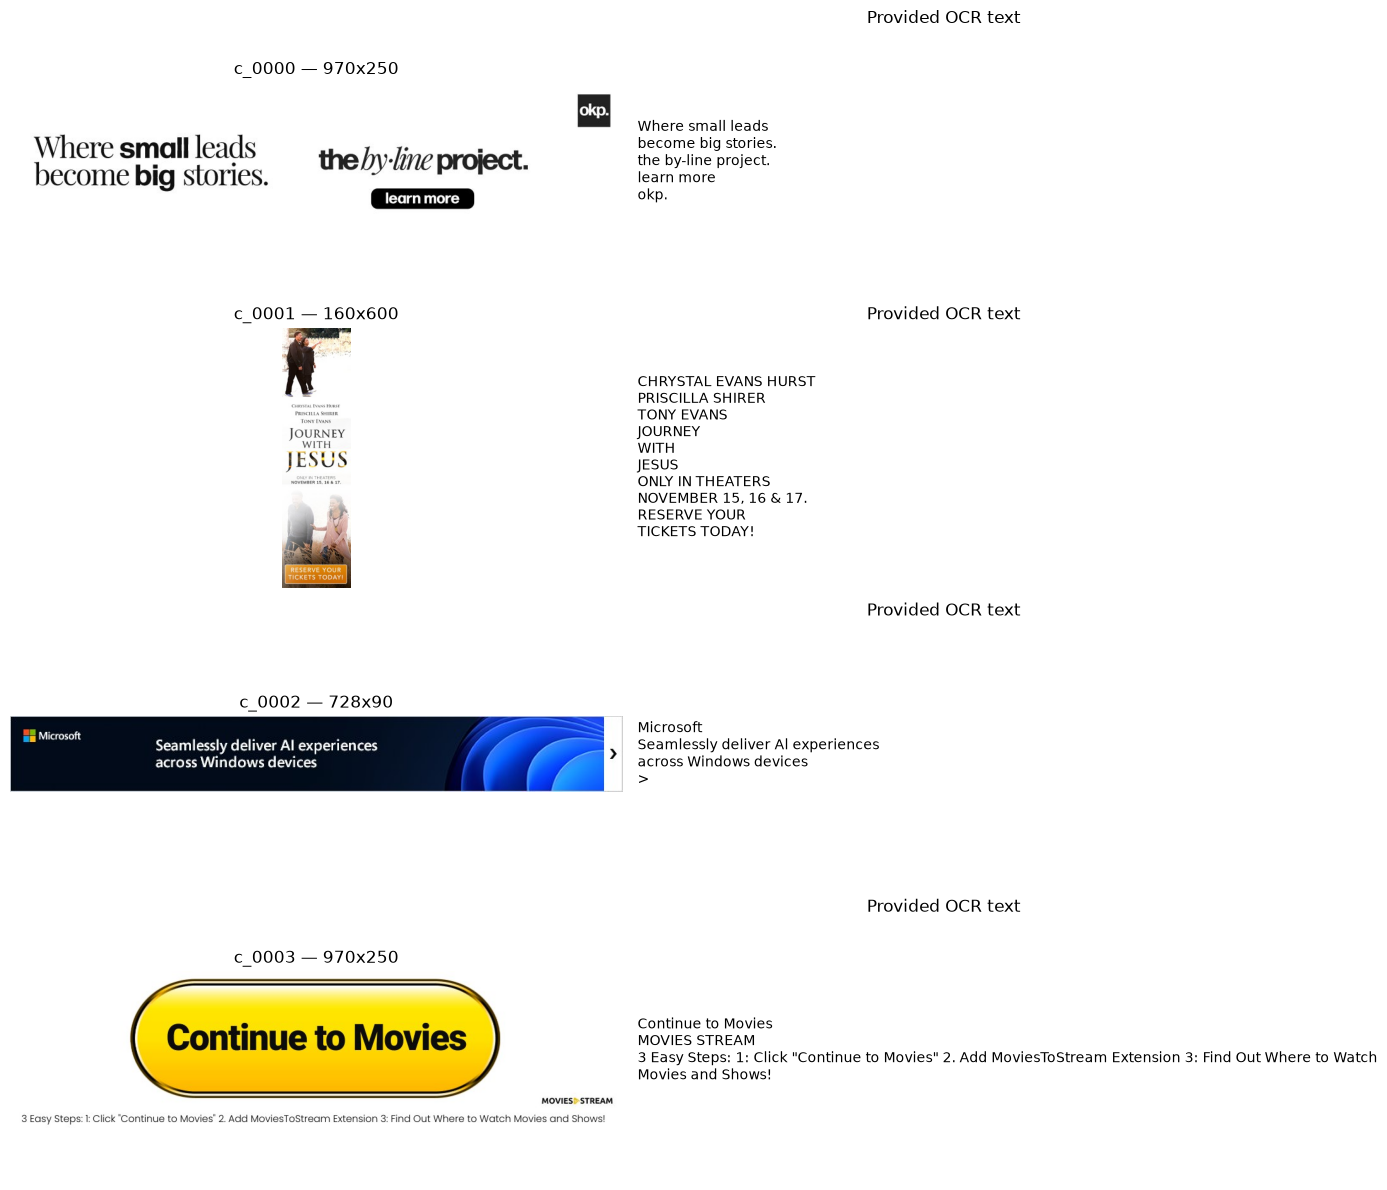

In [4]:

sample_indices = [0, 1, 2, 3]

fig, axes = plt.subplots(
    len(sample_indices),
    2,
    figsize=(14, 12),
)

for row, index in enumerate(sample_indices):

    creative = creatives.iloc[index]

    image = Image.open(
    PROJECT_ROOT / creative["image_path"]
)

    axes[row, 0].imshow(image)
    axes[row, 0].axis("off")
    axes[row, 0].set_title(
        f'{creative["creative_id"]} — {creative["ad_size"]}'
    )

    axes[row, 1].axis("off")
    axes[row, 1].text(
        0,
        0.5,
        creative["ad_text"],
        fontsize=10,
        va="center",
        wrap=True,
    )
    axes[row, 1].set_title("Provided OCR text")

plt.tight_layout()
plt.show()



## 4. Image encoder

CLIP converts each creative image into a dense semantic vector.

For our selected CLIP model:

**image → 512-dimensional vector**


In [5]:

processor, model, device = load_embedding_model()

print(f"Embedding device: {device}")

image_paths = [
    PROJECT_ROOT / path
    for path in creatives["image_path"]
]

image_embeddings = encode_images(
    image_paths,
    processor,
    model,
    device,
)

print(f"Image embeddings: {image_embeddings.shape}")


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Embedding device: mps


Encoding images: 100%|██████████| 91/91 [01:04<00:00,  1.41it/s]

Image embeddings: (2882, 512)



### Image embedding vector

The following plot shows the 512 dimensions of one image embedding.

Each dimension is a learned semantic feature rather than a human-interpretable pixel.


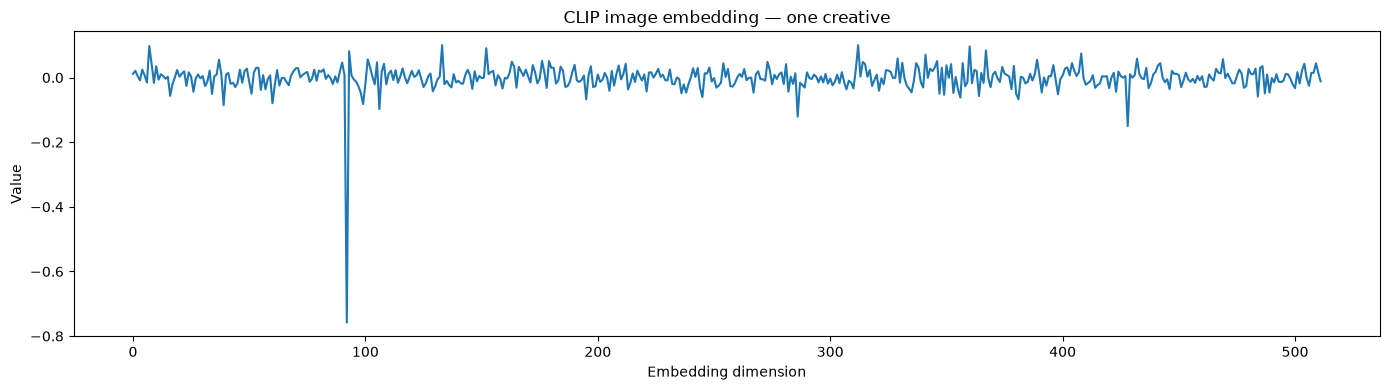

In [6]:

sample_image_embedding = image_embeddings[0]

plt.figure(figsize=(14, 4))

plt.plot(
    sample_image_embedding,
)

plt.xlabel("Embedding dimension")
plt.ylabel("Value")
plt.title(
    "CLIP image embedding — one creative"
)

plt.tight_layout()
plt.show()



### Image embedding dimension distribution


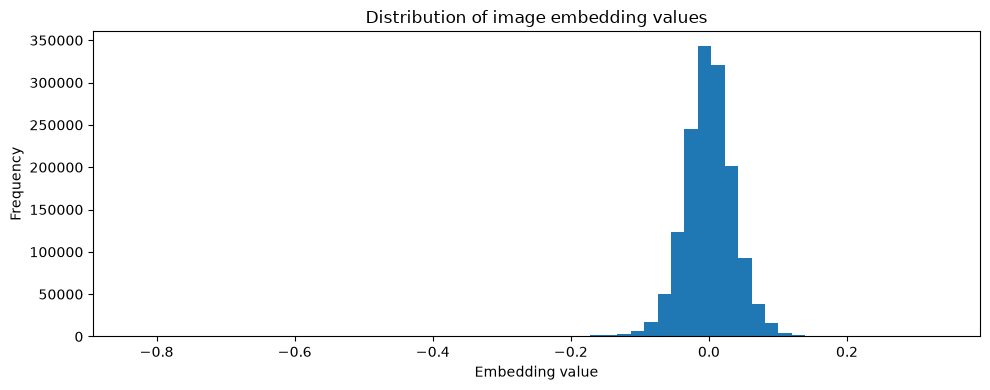

In [7]:

plt.figure(figsize=(10, 4))

plt.hist(
    image_embeddings.flatten(),
    bins=60,
)

plt.xlabel("Embedding value")
plt.ylabel("Frequency")
plt.title(
    "Distribution of image embedding values"
)

plt.tight_layout()
plt.show()



## 5. Text encoder

The supplied `ad_text` is noisy OCR extracted from the creative.

We apply only lightweight whitespace normalization and encode the resulting text with CLIP's text encoder.

**OCR text → 512-dimensional vector**


In [8]:

texts = creatives["ad_text"].tolist()

text_embeddings = encode_texts(
    texts,
    processor,
    model,
    device,
)

print(f"Text embeddings: {text_embeddings.shape}")


Encoding text: 100%|██████████| 91/91 [00:28<00:00,  3.24it/s]

Text embeddings: (2882, 512)



### Text embedding vector


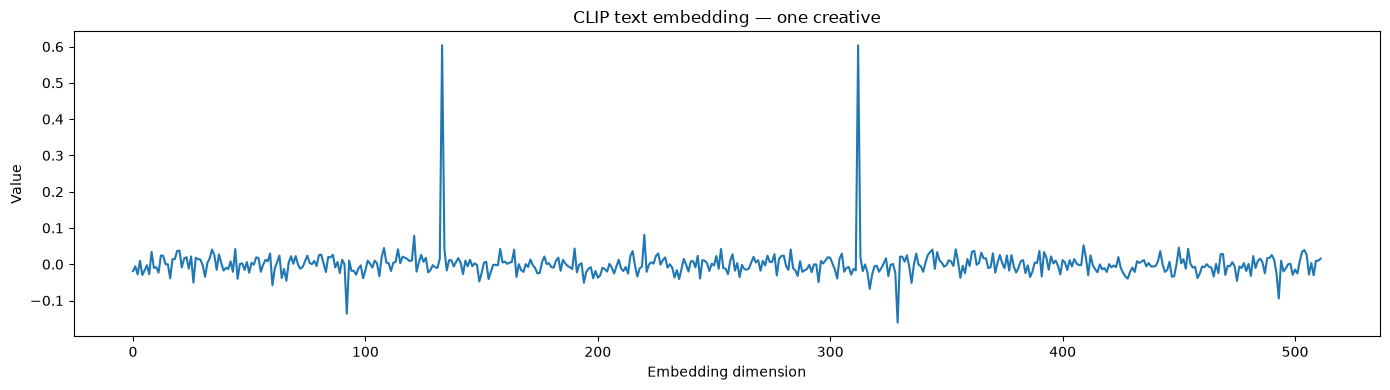

In [9]:

sample_text_embedding = text_embeddings[0]

plt.figure(figsize=(14, 4))

plt.plot(
    sample_text_embedding,
)

plt.xlabel("Embedding dimension")
plt.ylabel("Value")
plt.title(
    "CLIP text embedding — one creative"
)

plt.tight_layout()
plt.show()



## 6. Image vs text representation of the same creative

Image and text embeddings live in the same CLIP semantic space.

We can therefore compare the two modalities directly using cosine similarity.


Mean image-text similarity: 0.334


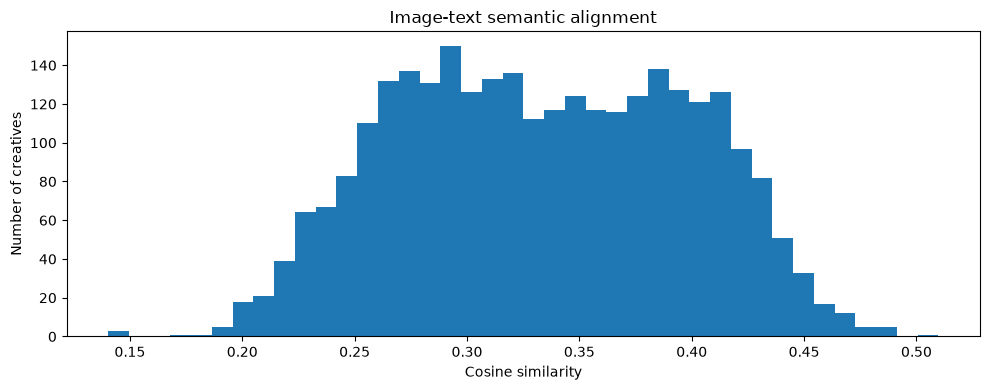

In [10]:

paired_similarity = np.sum(
    image_embeddings * text_embeddings,
    axis=1,
)

print(
    f"Mean image-text similarity: "
    f"{paired_similarity.mean():.3f}"
)

plt.figure(figsize=(10, 4))

plt.hist(
    paired_similarity,
    bins=40,
)

plt.xlabel("Cosine similarity")
plt.ylabel("Number of creatives")
plt.title(
    "Image-text semantic alignment"
)

plt.tight_layout()
plt.show()



### Most and least aligned image-text pairs

This is useful because the dataset explicitly tells us the OCR text can be noisy.


In [11]:

alignment = creatives[
    ["creative_id", "ad_text"]
].copy()

alignment["image_text_similarity"] = paired_similarity

print("Highest alignment:")
display(
    alignment.sort_values(
        "image_text_similarity",
        ascending=False,
    ).head(5)
)

print("Lowest alignment:")
display(
    alignment.sort_values(
        "image_text_similarity",
        ascending=True,
    ).head(5)
)


Highest alignment:


,creative_id,ad_text,image_text_similarity
1772,c_1772,Universal\nMUSIC\nFestival\n202\nVENTA DE\nENT...,0.509794
2426,c_2426,Buckeye FURNITURE\n& Mattress Center\nNominate...,0.487857
665,c_0665,"DOZER DAY\nMay 20th & 21st, 2023.\nSEATTLE DOZ...",0.487380
2365,c_2365,rbh\nSI Series\nSignature Quality\nDiscrete In...,0.486031
1535,c_1535,Academy\nSPORTS+OUTDOORS\nPRESENTS\n::HANG\nTE...,0.484650


Lowest alignment:


,creative_id,ad_text,image_text_similarity
1310,c_1310,Head Over Heels Photo\nWeddings\nFamily Photos...,0.140306
200,c_0200,JULIANNE MOORE\nGLORIA BELL\nBackup Plan\nARRI...,0.146860
516,c_0516,PALACE\nTHEATRE\nSt. Mary's Bank\n2002-2003\nP...,0.148884
2520,c_2520,FICC\nFayetteville Technical\nCommunity Colleg...,0.177155
1083,c_1083,ADVANTAGE\nHOME\nCONTRACTING\nA\nDESIGN & BUIL...,0.179614



## 7. Multimodal fusion

We combine the two normalized modalities:

**Fused = 0.5 × Image + 0.5 × Text**

and L2-normalize the result again.

The important point is that fusion remains **512-dimensional** rather than becoming 1024-dimensional.


In [12]:

fused_embeddings = fuse_embeddings(
    image_embeddings,
    text_embeddings,
)

print(f"Fused embeddings: {fused_embeddings.shape}")


Fused embeddings: (2882, 512)



### Image vs text vs fused vector


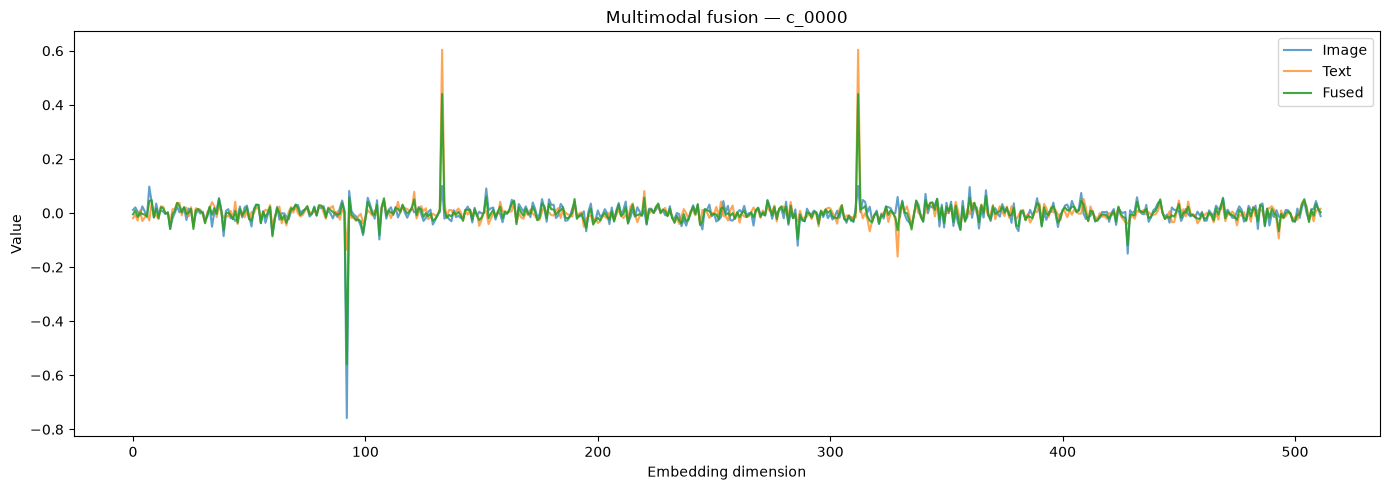

In [13]:

index = 0

plt.figure(figsize=(14, 5))

plt.plot(
    image_embeddings[index],
    label="Image",
    alpha=0.7,
)

plt.plot(
    text_embeddings[index],
    label="Text",
    alpha=0.7,
)

plt.plot(
    fused_embeddings[index],
    label="Fused",
    alpha=0.9,
)

plt.xlabel("Embedding dimension")
plt.ylabel("Value")
plt.title(
    f"Multimodal fusion — {creatives.iloc[index]['creative_id']}"
)

plt.legend()
plt.tight_layout()
plt.show()



## 8. L2 normalization check

After normalization, each embedding should have approximately unit L2 norm.

This matters because cosine similarity then directly measures angular similarity.


In [15]:
image_norms = np.linalg.norm(
    image_embeddings,
    axis=1,
)

text_norms = np.linalg.norm(
    text_embeddings,
    axis=1,
)

fused_norms = np.linalg.norm(
    fused_embeddings,
    axis=1,
)

norm_summary = pd.DataFrame({
    "Mean L2 Norm": [
        image_norms.mean(),
        text_norms.mean(),
        fused_norms.mean(),
    ],
    "Std L2 Norm": [
        image_norms.std(),
        text_norms.std(),
        fused_norms.std(),
    ],
    "Min L2 Norm": [
        image_norms.min(),
        text_norms.min(),
        fused_norms.min(),
    ],
    "Max L2 Norm": [
        image_norms.max(),
        text_norms.max(),
        fused_norms.max(),
    ],
    "Max Error From 1": [
        np.max(np.abs(image_norms - 1)),
        np.max(np.abs(text_norms - 1)),
        np.max(np.abs(fused_norms - 1)),
    ],
}, index=["Image", "Text", "Fused"])

display(norm_summary)

,Mean L2 Norm,Std L2 Norm,Min L2 Norm,Max L2 Norm,Max Error From 1
Image,1.0,4.230741e-08,1.0,1.0,1.192093e-07
Text,1.0,4.905384e-08,1.0,1.0,1.788139e-07
Fused,1.0,3.831678e-08,1.0,1.0,1.192093e-07



## 9. PCA visualization of the embedding spaces

PCA reduces the 512-dimensional representations to two dimensions **only for visualization**.

We compare the image, text and fused spaces.


In [16]:

pca = PCA(
    n_components=2,
    random_state=42,
)

image_2d = pca.fit_transform(
    image_embeddings
)

image_variance = pca.explained_variance_ratio_.sum()

pca = PCA(
    n_components=2,
    random_state=42,
)

text_2d = pca.fit_transform(
    text_embeddings
)

text_variance = pca.explained_variance_ratio_.sum()

pca = PCA(
    n_components=2,
    random_state=42,
)

fused_2d = pca.fit_transform(
    fused_embeddings
)

fused_variance = pca.explained_variance_ratio_.sum()

print(
    f"Explained variance — "
    f"Image: {image_variance:.1%}, "
    f"Text: {text_variance:.1%}, "
    f"Fused: {fused_variance:.1%}"
)


Explained variance — Image: 12.8%, Text: 7.9%, Fused: 8.4%


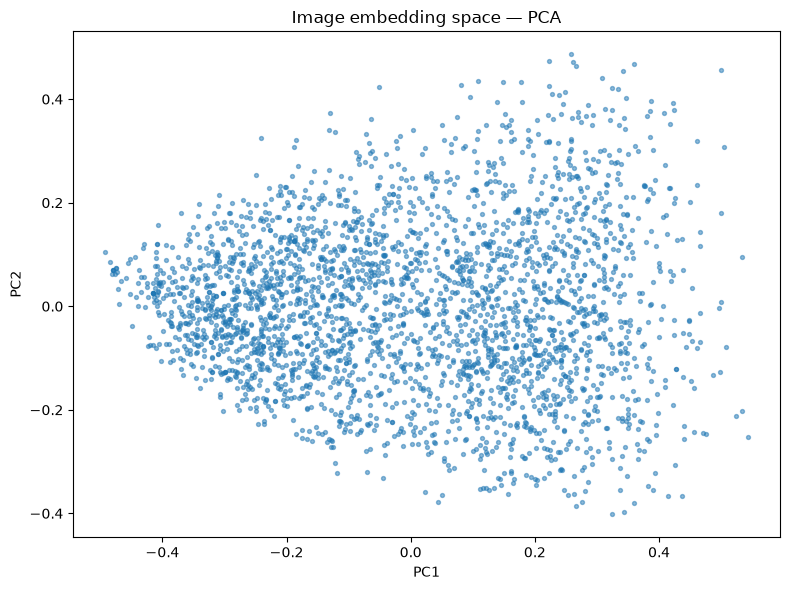

In [17]:

plt.figure(figsize=(8, 6))

plt.scatter(
    image_2d[:, 0],
    image_2d[:, 1],
    s=8,
    alpha=0.5,
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Image embedding space — PCA")

plt.tight_layout()
plt.show()


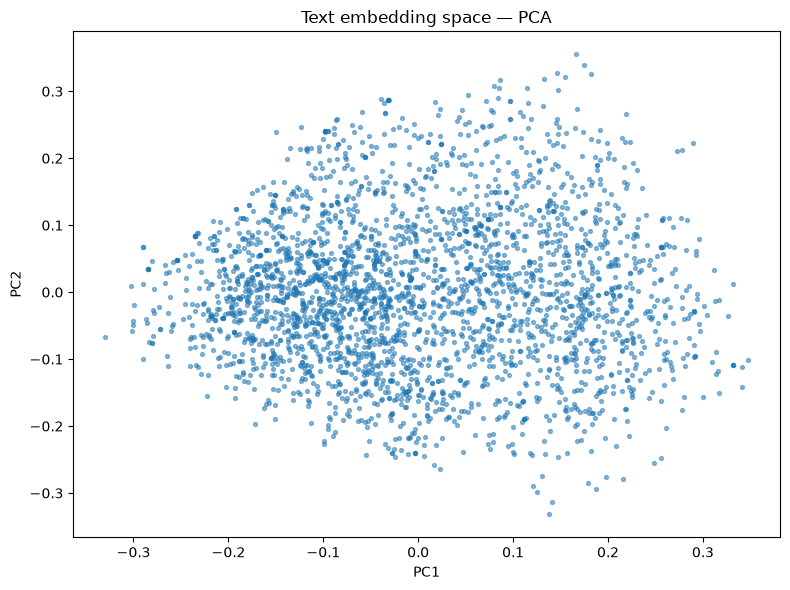

In [18]:

plt.figure(figsize=(8, 6))

plt.scatter(
    text_2d[:, 0],
    text_2d[:, 1],
    s=8,
    alpha=0.5,
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Text embedding space — PCA")

plt.tight_layout()
plt.show()


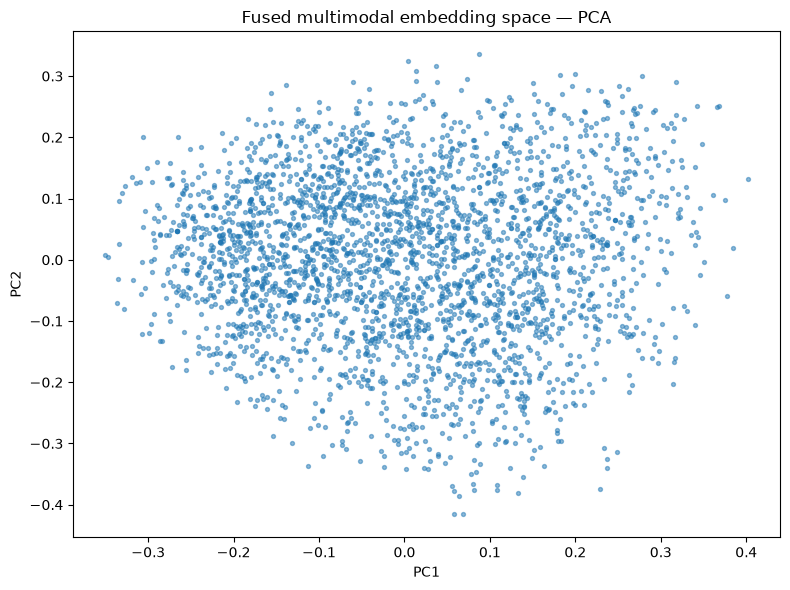

In [19]:

plt.figure(figsize=(8, 6))

plt.scatter(
    fused_2d[:, 0],
    fused_2d[:, 1],
    s=8,
    alpha=0.5,
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Fused multimodal embedding space — PCA")

plt.tight_layout()
plt.show()



## 10. Retrieval comparison

Now we test the practical purpose of the embeddings.

For one query creative, retrieve its nearest neighbors using:

- image embedding
- text embedding
- fused embedding

This helps us see whether fusion gives a more useful representation than either modality alone.


In [20]:

query_index = 0

def nearest_neighbors(
    embeddings,
    query_index,
    k=5,
):
    similarities = cosine_similarity(
        embeddings[query_index:query_index + 1],
        embeddings,
    )[0]

    neighbors = np.argsort(
        similarities
    )[::-1]

    neighbors = [
        index
        for index in neighbors
        if index != query_index
    ][:k]

    return neighbors, similarities[neighbors]


image_neighbors, image_scores = nearest_neighbors(
    image_embeddings,
    query_index,
)

text_neighbors, text_scores = nearest_neighbors(
    text_embeddings,
    query_index,
)

fused_neighbors, fused_scores = nearest_neighbors(
    fused_embeddings,
    query_index,
)

print("Query:", creatives.iloc[query_index]["creative_id"])


Query: c_0000


In [21]:

retrieval = pd.DataFrame({
    "rank": range(1, 6),
    "image_neighbor": [
        creatives.iloc[i]["creative_id"]
        for i in image_neighbors
    ],
    "image_similarity": image_scores,
    "text_neighbor": [
        creatives.iloc[i]["creative_id"]
        for i in text_neighbors
    ],
    "text_similarity": text_scores,
    "fused_neighbor": [
        creatives.iloc[i]["creative_id"]
        for i in fused_neighbors
    ],
    "fused_similarity": fused_scores,
})

display(retrieval)


,rank,image_neighbor,image_similarity,text_neighbor,text_similarity,fused_neighbor,fused_similarity
0,1,c_2737,0.858328,c_1601,0.995085,c_2418,0.935093
1,2,c_2418,0.853123,c_2418,0.983240,c_1601,0.910960
2,3,c_0043,0.825889,c_1418,0.856748,c_2737,0.868277
3,4,c_0696,0.825880,c_1122,0.853223,c_1129,0.833330
4,5,c_0481,0.822753,c_1139,0.852154,c_1122,0.832449



## 11. Qualitative fused retrieval

Visual inspection is important: a high cosine similarity should correspond to genuinely similar creatives, not merely similar dimensions or formatting.


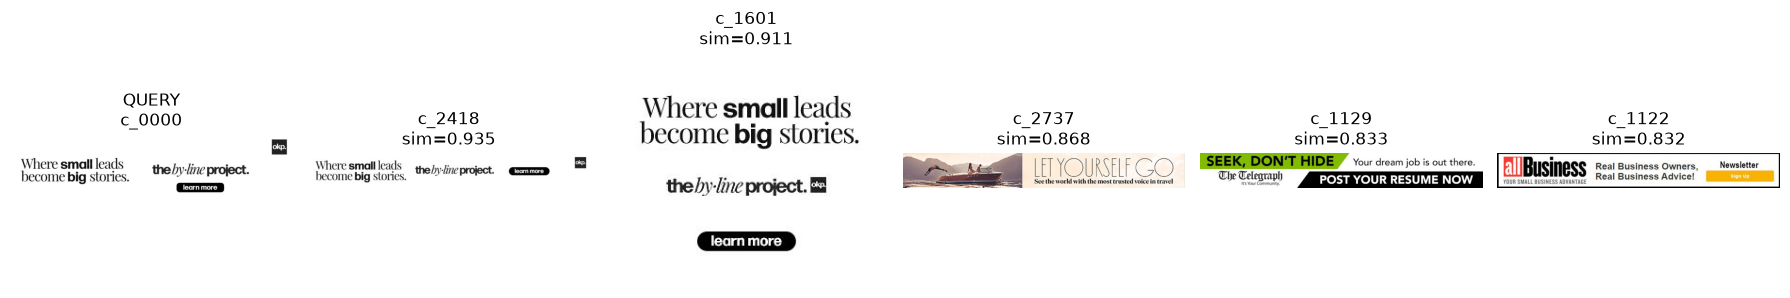

In [22]:

selected = [query_index] + list(fused_neighbors)

fig, axes = plt.subplots(
    1,
    len(selected),
    figsize=(18, 4),
)

for axis, index in zip(axes, selected):

    image = Image.open(
        PROJECT_ROOT / creatives.iloc[index]["image_path"]
    )

    axis.imshow(image)
    axis.axis("off")

    if index == query_index:
        title = (
            f"QUERY\n"
            f"{creatives.iloc[index]['creative_id']}"
        )
    else:
        score = cosine_similarity(
            fused_embeddings[
                query_index:query_index + 1
            ],
            fused_embeddings[
                index:index + 1
            ],
        )[0, 0]

        title = (
            f"{creatives.iloc[index]['creative_id']}\n"
            f"sim={score:.3f}"
        )

    axis.set_title(title)

plt.tight_layout()
plt.show()


In [23]:
from srcA.embeddings import (
    build_embedding_metadata,
    save_embeddings,
)

# Keep embedding rows aligned with the original creatives
metadata = build_embedding_metadata(creatives)

# Save image, text, fused embeddings and metadata
save_embeddings(
    image_embeddings=image_embeddings,
    text_embeddings=text_embeddings,
    fused_embeddings=fused_embeddings,
    metadata=metadata,
)

print("Embeddings saved successfully.")

Embeddings saved successfully.


In [24]:
np.save(IMAGE_EMBEDDINGS_PATH, image_embeddings)
np.save(TEXT_EMBEDDINGS_PATH, text_embeddings)
np.save(FUSED_EMBEDDINGS_PATH, fused_embeddings)
metadata.to_parquet(EMBEDDING_METADATA_PATH, index=False)


## 12. Embedding conclusions

Record observations here after running the notebook.

Things to evaluate:

- Are image and text representations both well-formed 512D vectors?
- How strong is image-text semantic alignment?
- Does fusion produce meaningful neighbors?
- Are near-duplicate creatives close together?
- Does fusion retrieve semantically similar creatives better than image-only or text-only retrieval?
- Are there OCR-heavy creatives where the image representation provides useful information?
- Are there visually similar but semantically different creatives where text helps disambiguate?

These observations will inform the duplicate detector and persona retrieval model.
